# 1.1 Effective Programming with AI-Assisted Refinement

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

## References
1. [Burkov, A. (2019) The One Hundred Page Machine Learning Book](http://ema.cri-info.cm/wp-content/uploads/2019/07/2019BurkovTheHundred-pageMachineLearning.pdf) - Required Textbook.
2. [Molnar, C. (2022). Interpretable Machine Learning: A Guide for Making Black Box Models Explainable.](https://christophm.github.io/interpretable-ml-book/) This book provides insights into understanding AI-generated models and results, reinforcing the importance of interpretability in human-AI collaboration.
3. [ChatGPT & AI-Assisted Programming (2025).](https://openai.com/chatgpt/overview/) This lesson itself serves as a reference on how to effectively collaborate with AI for refining and improving machine learning scripts. It illustrates the incremental development approach, showing how AI can assist in modularization, error handling, and output enhancement while ensuring human oversight remains crucial.

This section discusses how to leverage Open Source AI tools, such as ChatGPT and similar assistants, to help you write and refine your scripts for machine learning processing tasks.

## Workflow: AI-Assisted Code Improvement

To build effective scripts, start with a working (but possibly crude) implementation, then use AI tools iteratively to improve it. Do not attempt multiple refinements at once—test each change incrementally to ensure it aligns with your modeling objectives.

Suggested Improvement Sequence:

1. Improve Functionality

- AI tools typically suggest modularizing repetitive structures into functions.
- They may introduce best practices, such as avoiding hardcoded values and optimizing loops.
  - Caution: Test changes one at a time to prevent breaking the script, and identify where errors occur.

2. Enhance Modularity:
- Convert repeated operations into well-defined functions or classes for better code organization.
- Use parameterized functions to make modifications easier.
  - Example: If a data preprocessing step is repeated, define a function instead of copy-pasting code.

3. Implement Error Handling and Defaults

- Trap user input errors and ensure the script fails gracefully rather than crashing.
- Use default settings to allow processing to continue if invalid inputs are detected.
  - Example: AI can help implement try-except blocks for handling missing data or type mismatches.

4. Improve Output Readability
- AI can suggest better logging and reporting mechanisms to make outputs more informative.
- Format tables, charts, and print statements to enhance clarity.
  - Example: Instead of raw lists or dictionaries, output results using pandas DataFrames or formatted plots.

Next, we will walk through an example, starting with a basic script and refining it using AI tools. We will test and validate each modification to ensure it aligns with our intended machine learning workflow.

## Example Script: Illustrate AI-Assisted Code Refinement

This script:
- Generates synthetic data (simulating a small dataset)
- Prepares the data (splits into training & testing sets)
- Trains a simple model (linear regression)
- Evaluates the model (computes RMSE)

### Step 1: Crude, Working Script
This is a basic version—it works, but it is not well-structured. This is a necessary **human** created starting point.

RMSE: 3.0218132428280766


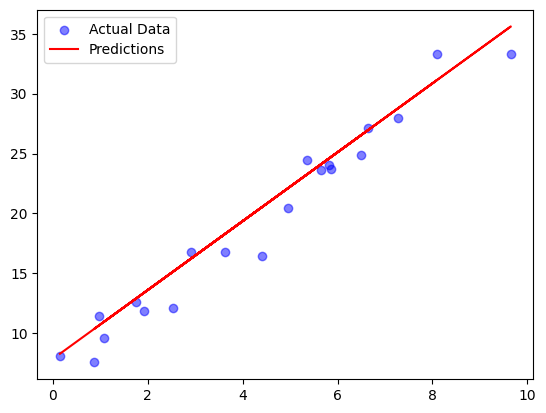

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate synthetic dataset
np.random.seed(75)
X = np.random.rand(100, 1) * 10  # Feature: Random values between 0 and 10
y = 3 * X + 7 + np.random.randn(100, 1) * 2  # Target: Linear function with noise

# Train-test split (80-20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
rmse = mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

# Plot results
plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
plt.plot(X_test, y_pred, label="Predictions", color="red")
plt.legend()
plt.show()


### Step 2: AI-Assisted Refinement
After sending the script to ChatGPT, we may receive recommendations to:

1. Modularize the script (convert it into functions).
2. Add error handling for invalid inputs.
3. Enhance output readability.

**Modularized Version** generated by ChatGPT
- Each logical step is now a separate function.
- Main execution logic is at the bottom.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def generate_synthetic_data(seed=75, size=100):
    """Generates synthetic dataset with a linear relationship and noise."""
    np.random.seed(seed)
    X = np.random.rand(size, 1) * 10  # Feature: Random values between 0 and 10
    y = 3 * X + 7 + np.random.randn(size, 1) * 2  # Target: Linear function with noise
    return X, y

def train_test_split(X, y, split_ratio=0.8):
    """Splits data into training and testing sets based on the given ratio."""
    split = int(split_ratio * len(X))
    return X[:split], X[split:], y[:split], y[split:]

def train_model(X_train, y_train):
    """Trains a linear regression model on the training data."""
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluates the trained model and returns RMSE and predictions."""
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    return rmse, y_pred

def plot_results(X_test, y_test, y_pred):
    """Plots actual vs. predicted values."""
    plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
    plt.plot(X_test, y_pred, label="Predictions", color="red")
    plt.legend()
    plt.show()

# Main script execution
X, y = generate_synthetic_data()
X_train, X_test, y_train, y_test = train_test_split(X, y)
model = train_model(X_train, y_train)
rmse, y_pred = evaluate_model(model, X_test, y_test)

print("RMSE:", rmse)
plot_results(X_test, y_test, y_pred)


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required by LinearRegression.

What’s Improved?
- Code is easier to read & maintain (each function handles a specific task).
- Testing becomes simpler (can test individual functions separately).
- Future modifications are easier (e.g., swapping models, adjusting data parameters).

### Step 3.  AI Assisted Error Handling Components

Again using ChatGPT it will produce another refinement with input validation and error trapping.  The key improvements are:

- Check for invalid data types (e.g., if non-numeric data is passed).
- Handle cases where input arrays are empty or too small.
- Ensure train-test split has enough data.
- Catch unexpected errors gracefully.

In practice I would implement the changes one-at-a time, to illustrate the handling in lecture, we will simply generate the dataset in the main program with `size=0` which will issue an error, stop execution, and supply a cryptic explaination of the cause of the exception.

RMSE: 3.0218132428280766


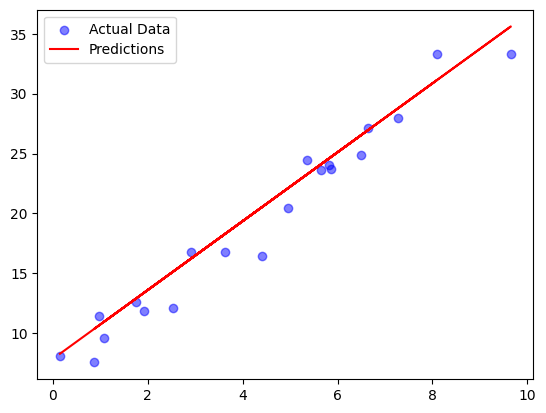

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def generate_synthetic_data(seed=75, size=100):
    """Generates synthetic dataset with a linear relationship and noise."""
    if not isinstance(size, int) or size <= 0:
        raise ValueError("Size must be a positive integer.")
    
    np.random.seed(seed)
    X = np.random.rand(size, 1) * 10  # Feature: Random values between 0 and 10
    y = 3 * X + 7 + np.random.randn(size, 1) * 2  # Target: Linear function with noise
    return X, y

def train_test_split(X, y, split_ratio=0.8):
    """Splits data into training and testing sets with basic error checks."""
    if not isinstance(split_ratio, float) or not (0 < split_ratio < 1):
        raise ValueError("Split ratio must be a float between 0 and 1.")
    
    if len(X) != len(y):
        raise ValueError("Feature and target arrays must have the same length.")
    
    split = int(split_ratio * len(X))
    if split == 0 or split == len(X):  # Ensure valid split
        raise ValueError("Data split resulted in an empty training or testing set.")

    return X[:split], X[split:], y[:split], y[split:]

def train_model(X_train, y_train):
    """Trains a linear regression model, checking for invalid data."""
    if X_train.size == 0 or y_train.size == 0:
        raise ValueError("Training data cannot be empty.")
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluates the trained model, checking for valid test data."""
    if X_test.size == 0 or y_test.size == 0:
        raise ValueError("Testing data cannot be empty.")
    
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)
    return rmse, y_pred

def plot_results(X_test, y_test, y_pred):
    """Plots actual vs. predicted values with error handling."""
    if X_test.size == 0 or y_test.size == 0:
        print("Skipping plot: No valid test data.")
        return
    
    plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
    plt.plot(X_test, y_pred, label="Predictions", color="red")
    plt.legend()
    plt.show()

# Main script execution with error handling
try:
    X, y = generate_synthetic_data(size=100)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model = train_model(X_train, y_train)
    rmse, y_pred = evaluate_model(model, X_test, y_test)

    print("RMSE:", rmse)
    plot_results(X_test, y_test, y_pred)

except Exception as e:
    print("Error:", str(e))


What’s Improved?
- Prevents common errors like negative dataset sizes, invalid split ratios, or empty datasets.
- Ensures input consistency before passing data to machine learning functions.
- Gracefully handles errors with try-except, instead of crashing the script.

### Step 4. AI assistance to  improve output readability by:

- Formatting console messages for clarity.
- Adding better labels to plots.
- Using print statements with structured output (e.g., table-like formatting).
- Introducing optional logging for structured debugging (optional, but useful).


=== Running Machine Learning Script ===

[INFO] Generated dataset with 100 samples.
[INFO] Split dataset: 80 train samples, 20 test samples.
[INFO] Model trained successfully.

=== Model Evaluation ===
  RMSE: 3.0218
  Model Coefficients: 2.875
  Intercept: 7.861



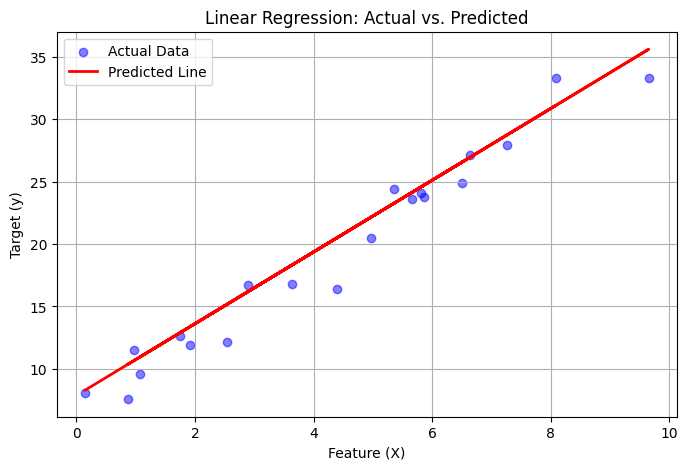

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def generate_synthetic_data(seed=75, size=100):
    """Generates synthetic dataset with a linear relationship and noise."""
    if not isinstance(size, int) or size <= 0:
        raise ValueError("Size must be a positive integer.")
    
    np.random.seed(seed)
    X = np.random.rand(size, 1) * 10  # Feature: Random values between 0 and 10
    y = 3 * X + 7 + np.random.randn(size, 1) * 2  # Target: Linear function with noise
    print(f"[INFO] Generated dataset with {size} samples.")
    return X, y

def train_test_split(X, y, split_ratio=0.8):
    """Splits data into training and testing sets with basic error checks."""
    if not isinstance(split_ratio, float) or not (0 < split_ratio < 1):
        raise ValueError("Split ratio must be a float between 0 and 1.")
    
    if len(X) != len(y):
        raise ValueError("Feature and target arrays must have the same length.")
    
    split = int(split_ratio * len(X))
    if split == 0 or split == len(X):  
        raise ValueError("Data split resulted in an empty training or testing set.")

    print(f"[INFO] Split dataset: {split} train samples, {len(X) - split} test samples.")
    return X[:split], X[split:], y[:split], y[split:]

def train_model(X_train, y_train):
    """Trains a linear regression model, checking for invalid data."""
    if X_train.size == 0 or y_train.size == 0:
        raise ValueError("Training data cannot be empty.")
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    print("[INFO] Model trained successfully.")
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluates the trained model, checking for valid test data."""
    if X_test.size == 0 or y_test.size == 0:
        raise ValueError("Testing data cannot be empty.")
    
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)

    print("\n=== Model Evaluation ===")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Model Coefficients: {model.coef_[0][0]:.3f}")
    print(f"  Intercept: {model.intercept_[0]:.3f}\n")

    return rmse, y_pred

def plot_results(X_test, y_test, y_pred):
    """Plots actual vs. predicted values with labels and improved visualization."""
    if X_test.size == 0 or y_test.size == 0:
        print("[WARNING] Skipping plot: No valid test data.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
    plt.plot(X_test, y_pred, label="Predicted Line", color="red", linewidth=2)
    plt.xlabel("Feature (X)")
    plt.ylabel("Target (y)")
    plt.title("Linear Regression: Actual vs. Predicted")
    plt.legend()
    plt.grid(True)
    plt.show()

# Main script execution with error handling
try:
    print("\n=== Running Machine Learning Script ===\n")
    X, y = generate_synthetic_data(size=100)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model = train_model(X_train, y_train)
    rmse, y_pred = evaluate_model(model, X_test, y_test)

    plot_results(X_test, y_test, y_pred)

except Exception as e:
    print("[ERROR]", str(e))


What’s Improved?
1. Clearer Console Output
  - [INFO] messages indicate successful steps.
  - [WARNING] and [ERROR] messages help with debugging.
  - Formatted RMSE, coefficients, and intercept for easy readability.

2. Better Plot Presentation
  - Labeled axes, title, and grid for clarity.
  - Bigger figure size for better visualization.

3. Easier Debugging
  - If anything goes wrong, the error messages are structured and informative.

We now have a fully structured, AI-assisted machine learning script.  Remember, we had to start with something that already works to some extent, the AI tools can interpret directives and produce working scripts, but it is a far better man-machine interaction if we start with something we wrote, and therefore understand our goals.

What the AI did was save a lot of time, we could have implemented all these changes ourselves -- but would have spent a lot of time to learn how to do certain refinements.

:::{note}
Below is an example to be performed "live" in lecture.  From the last script I prompted the AI with `Can you put in the plot title the RMSE value (i.e. ".../n RMSE =" + repr(round(rmse,4))  or something similar`

```python
def plot_results(X_test, y_test, y_pred, rmse):
    """Plots actual vs. predicted values with RMSE in the title."""
    if X_test.size == 0 or y_test.size == 0:
        print("[WARNING] Skipping plot: No valid test data.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
    plt.plot(X_test, y_pred, label="Predicted Line", color="red", linewidth=2)
    plt.xlabel("Feature (X)")
    plt.ylabel("Target (y)")
    plt.title(f"Linear Regression: Actual vs. Predicted\nRMSE = {rmse:.4f}")# Changed here
    plt.legend()
    plt.grid(True)
    plt.show()

```

Below the change is inserted, and script run again.
:::


=== Running Machine Learning Script ===

[INFO] Generated dataset with 100 samples.
[INFO] Split dataset: 80 train samples, 20 test samples.
[INFO] Model trained successfully.

=== Model Evaluation ===
  RMSE: 3.0218
  Model Coefficients: 2.875
  Intercept: 7.861



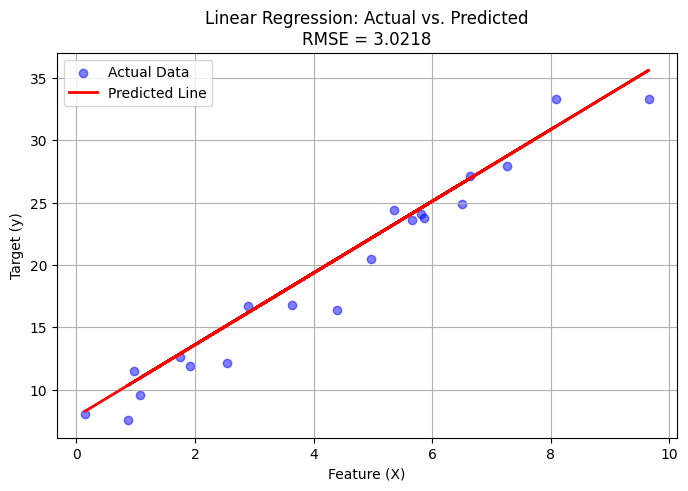

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def generate_synthetic_data(seed=75, size=100):
    """Generates synthetic dataset with a linear relationship and noise."""
    if not isinstance(size, int) or size <= 0:
        raise ValueError("Size must be a positive integer.")
    
    np.random.seed(seed)
    X = np.random.rand(size, 1) * 10  # Feature: Random values between 0 and 10
    y = 3 * X + 7 + np.random.randn(size, 1) * 2  # Target: Linear function with noise
    print(f"[INFO] Generated dataset with {size} samples.")
    return X, y

def train_test_split(X, y, split_ratio=0.8):
    """Splits data into training and testing sets with basic error checks."""
    if not isinstance(split_ratio, float) or not (0 < split_ratio < 1):
        raise ValueError("Split ratio must be a float between 0 and 1.")
    
    if len(X) != len(y):
        raise ValueError("Feature and target arrays must have the same length.")
    
    split = int(split_ratio * len(X))
    if split == 0 or split == len(X):  
        raise ValueError("Data split resulted in an empty training or testing set.")

    print(f"[INFO] Split dataset: {split} train samples, {len(X) - split} test samples.")
    return X[:split], X[split:], y[:split], y[split:]

def train_model(X_train, y_train):
    """Trains a linear regression model, checking for invalid data."""
    if X_train.size == 0 or y_train.size == 0:
        raise ValueError("Training data cannot be empty.")
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    print("[INFO] Model trained successfully.")
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluates the trained model, checking for valid test data."""
    if X_test.size == 0 or y_test.size == 0:
        raise ValueError("Testing data cannot be empty.")
    
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred)

    print("\n=== Model Evaluation ===")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Model Coefficients: {model.coef_[0][0]:.3f}")
    print(f"  Intercept: {model.intercept_[0]:.3f}\n")

    return rmse, y_pred

def plot_results(X_test, y_test, y_pred):
    """Plots actual vs. predicted values with labels and improved visualization."""
    if X_test.size == 0 or y_test.size == 0:
        print("[WARNING] Skipping plot: No valid test data.")
        return
    
    plt.figure(figsize=(8, 5))
    plt.scatter(X_test, y_test, label="Actual Data", color="blue", alpha=0.5)
    plt.plot(X_test, y_pred, label="Predicted Line", color="red", linewidth=2)
    plt.xlabel("Feature (X)")
    plt.ylabel("Target (y)")
    #plt.title("Linear Regression: Actual vs. Predicted")
    plt.title(f"Linear Regression: Actual vs. Predicted\nRMSE = {rmse:.4f}")# Changed here
    plt.legend()
    plt.grid(True)
    plt.show()

# Main script execution with error handling
try:
    print("\n=== Running Machine Learning Script ===\n")
    X, y = generate_synthetic_data(size=100)
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    model = train_model(X_train, y_train)
    rmse, y_pred = evaluate_model(model, X_test, y_test)

    plot_results(X_test, y_test, y_pred)

except Exception as e:
    print("[ERROR]", str(e))


## Section End